# Exploratory Data Analysis

Loads the raw returns data saved by notebook 01 and explores:
- Return distributions per stock
- Correlation structure
- Rolling statistics
- Annualized risk / return per asset

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.visualization.plots import (
    plot_correlation_heatmap,
    plot_return_distributions,
    plot_risk_return_scatter,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [2]:
log_returns = pd.read_csv('../data/raw/stock_log_returns.csv', index_col='Date', parse_dates=True)
returns     = pd.read_csv('../data/raw/stock_returns.csv',     index_col='Date', parse_dates=True)

# Keep only numeric columns (drop any residual non-numeric)
log_returns = log_returns.select_dtypes(include='number')
returns     = returns.select_dtypes(include='number')

print(f'Shape: {returns.shape}')
print(returns.head(3))

Shape: (1255, 11)
                AAPL      AMZN     GOOGL       JNJ       JPM      MSFT  \
Date                                                                     
2020-01-03 -0.009722 -0.012139 -0.005231 -0.011578 -0.013197 -0.012452   
2020-01-06  0.007969  0.014886  0.026654 -0.001248 -0.000795  0.002585   
2020-01-07 -0.004703  0.002092 -0.001932  0.006107 -0.017001 -0.009118   

                 PFE       UNH         V       WMT       XOM  
Date                                                          
2020-01-03 -0.005365 -0.010119 -0.007953 -0.008828 -0.008039  
2020-01-06 -0.001285  0.006942 -0.002162 -0.002035  0.007678  
2020-01-07 -0.003344 -0.006037 -0.002643 -0.009265 -0.008184  


In [3]:
# Descriptive statistics
desc = returns.describe().T
desc['skew']     = returns.skew()
desc['kurtosis'] = returns.kurtosis()
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
AAPL,1255.0,0.001200,0.019966,-0.128647,-0.008423,0.001234,0.012044,0.119808,0.103270,5.273229
AMZN,1255.0,0.000940,0.022669,-0.140494,-0.011107,0.000797,0.012968,0.135359,0.068339,3.989197
GOOGL,1255.0,0.001038,0.020485,-0.116341,-0.009514,0.001845,0.011435,0.102244,-0.058050,3.578774
JNJ,1255.0,0.000182,0.012385,-0.072984,-0.005727,0.000122,0.005922,0.079977,0.435196,8.301082
JPM,1255.0,0.000752,0.020505,-0.149648,-0.008412,0.000709,0.009905,0.180124,0.447149,12.929297
MSFT,1255.0,0.001006,0.019221,-0.147390,-0.008144,0.001115,0.010953,0.142169,-0.019297,7.116303
PFE,1255.0,0.000055,0.017318,-0.077347,-0.009448,-0.000833,0.008380,0.108552,0.368424,3.895244
UNH,1255.0,0.000680,0.018840,-0.172769,-0.007545,0.000827,0.008799,0.127989,-0.163112,12.632255
V,1255.0,0.000590,0.017577,-0.135472,-0.007732,0.001255,0.008798,0.138426,0.271637,10.414705
WMT,1255.0,0.000829,0.014227,-0.113757,-0.005765,0.000777,0.007341,0.117085,0.068646,14.059428


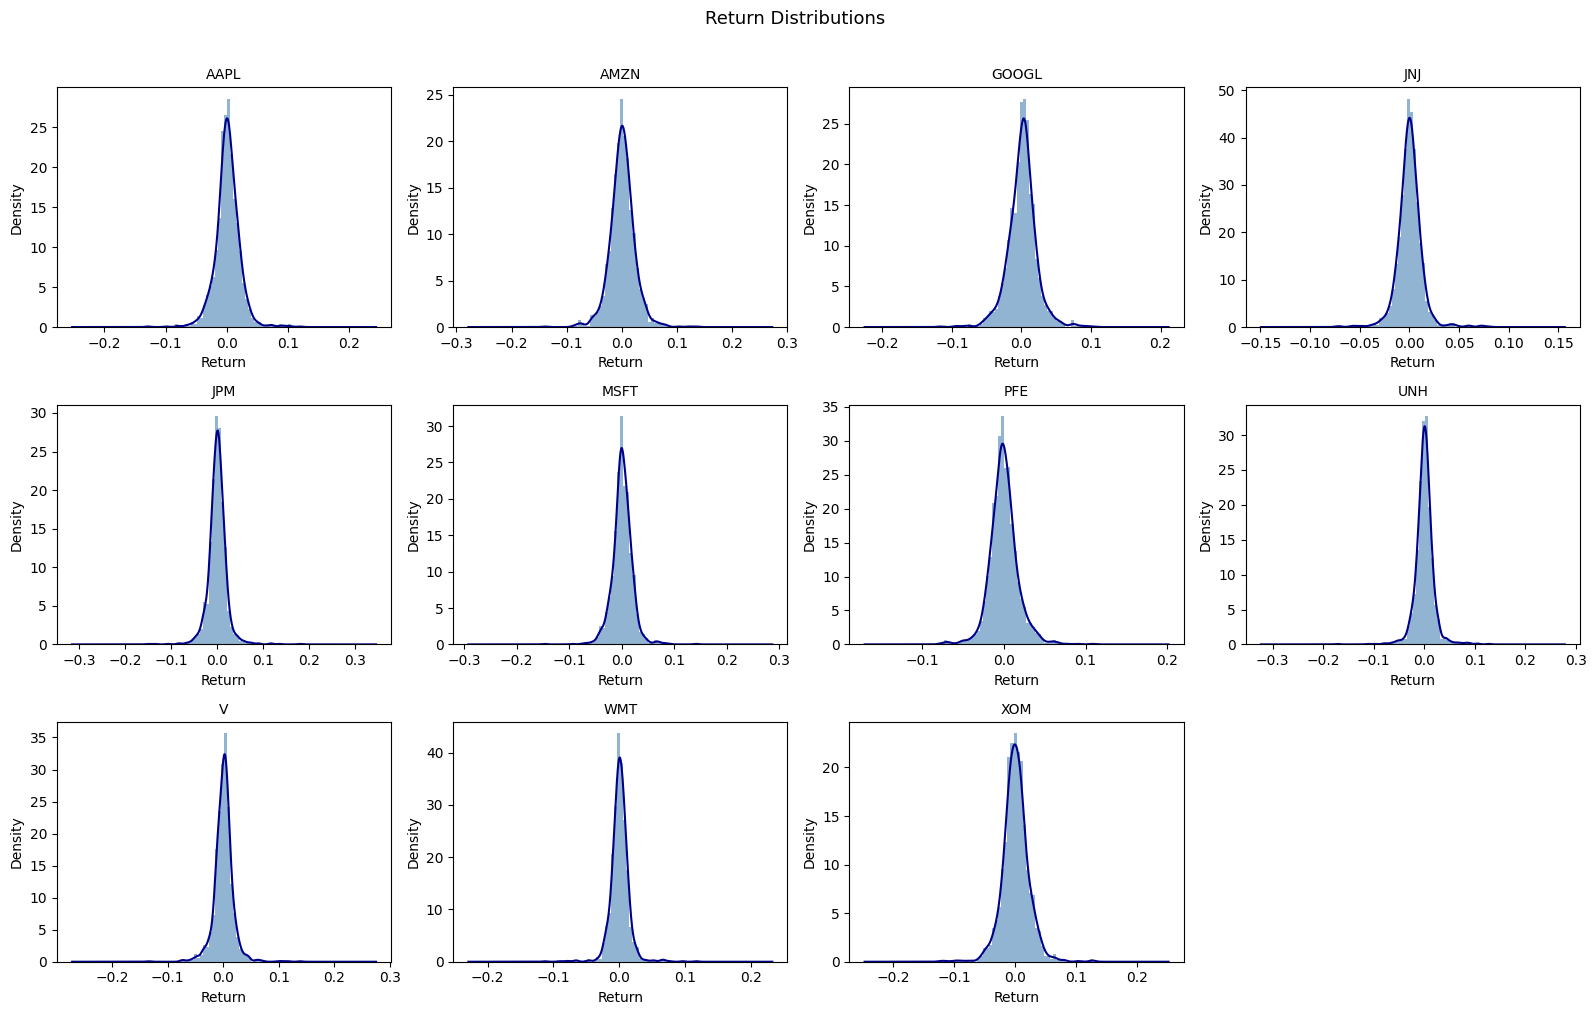

In [4]:
# Return distribution histograms
fig = plot_return_distributions(returns, figsize=(16, 10))
plt.show()

In [5]:
# Annualised risk / return per asset
periods = 252
ann_return = returns.mean() * periods
ann_vol    = returns.std(ddof=1) * np.sqrt(periods)

stats_df = pd.DataFrame({'Annualised Return': ann_return,
                         'Annualised Volatility': ann_vol})
stats_df['Sharpe (rf=2%)'] = (ann_return - 0.02) / ann_vol
print(stats_df.round(4))

       Annualised Return  Annualised Volatility  Sharpe (rf=2%)
AAPL              0.3024                 0.3170          0.8911
AMZN              0.2370                 0.3599          0.6029
GOOGL             0.2616                 0.3252          0.7431
JNJ               0.0458                 0.1966          0.1314
JPM               0.1894                 0.3255          0.5206
MSFT              0.2536                 0.3051          0.7655
PFE               0.0138                 0.2749         -0.0226
UNH               0.1713                 0.2991          0.5059
V                 0.1486                 0.2790          0.4609
WMT               0.2089                 0.2258          0.8364
XOM               0.1895                 0.3440          0.4928


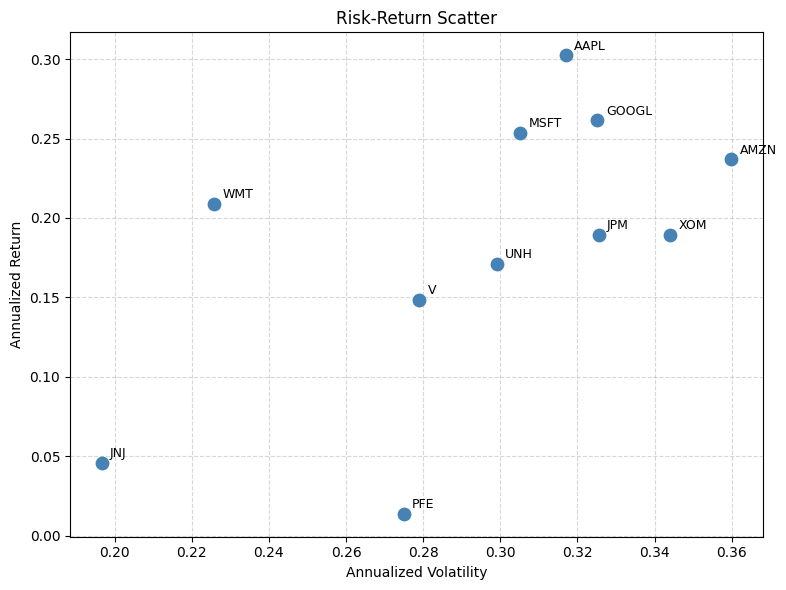

In [6]:
fig = plot_risk_return_scatter(
    mean_returns=ann_return.values,
    volatilities=ann_vol.values,
    labels=list(returns.columns),
)
plt.show()

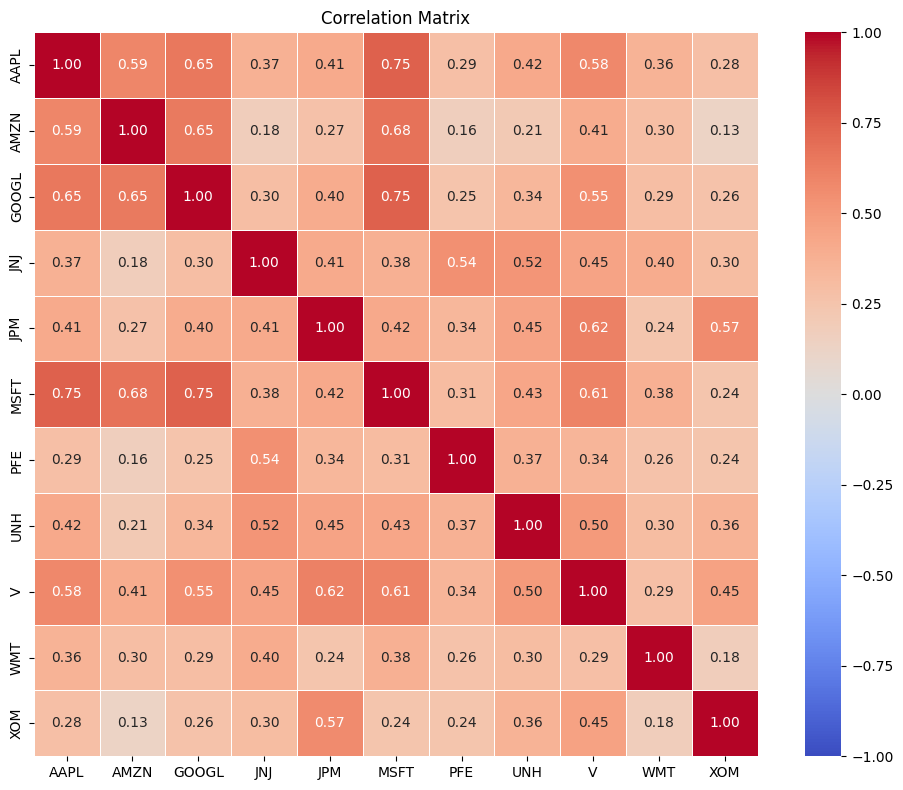

In [7]:
# Correlation heatmap
fig = plot_correlation_heatmap(returns.corr())
plt.show()

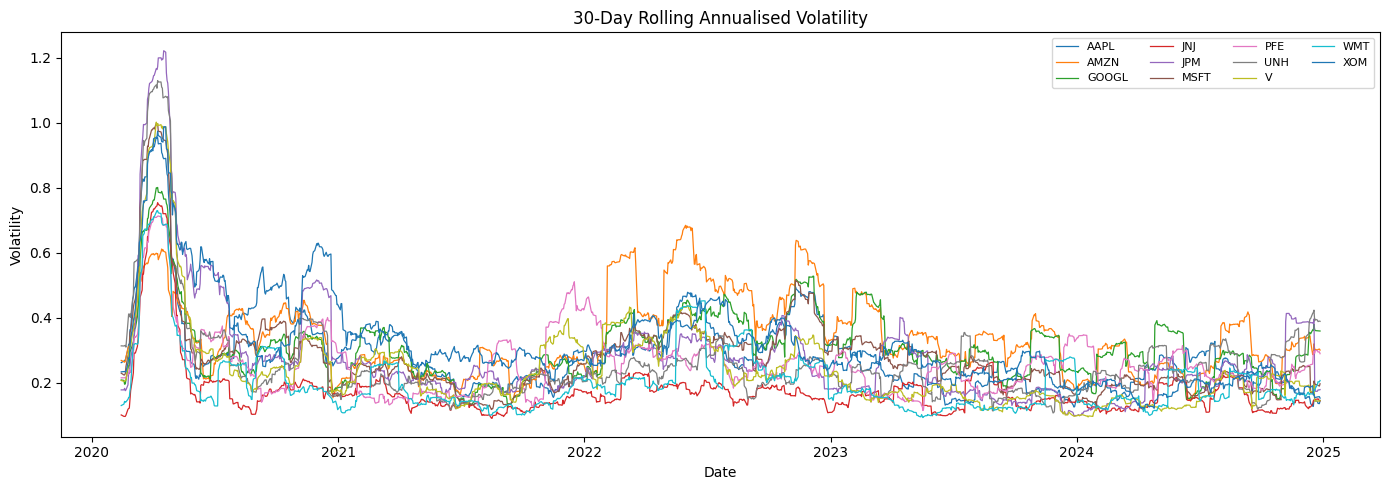

In [8]:
# 30-day rolling volatility for each ticker
roll_vol = returns.rolling(30).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 5))
for col in roll_vol.columns:
    ax.plot(roll_vol.index, roll_vol[col], linewidth=0.9, label=col)
ax.set_title('30-Day Rolling Annualised Volatility')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility')
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()